In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
df = pd.read_csv('shopping_trends.csv')

In [4]:
# Display data
df.head()


,Customer ID,Age,Gender,Item Purchased,Category,Purchase_Amount,Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   str    
 3   Item Purchased            3900 non-null   str    
 4   Category                  3900 non-null   str    
 5   Purchase_Amount           3900 non-null   int64  
 6   Location                  3900 non-null   str    
 7   Size                      3900 non-null   str    
 8   Color                     3900 non-null   str    
 9   Season                    3900 non-null   str    
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   str    
 12  Payment Method            3900 non-null   str    
 13  Shipping Type             3900 non-null   str    
 14  Discount Applied   

In [6]:
# Check missing values
print(df.isnull().sum())

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase_Amount             0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64


In [7]:
# Drop missing values
df = df.dropna()

In [8]:
# Basic statistics
df.describe()

,Customer ID,Age,Purchase_Amount,Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


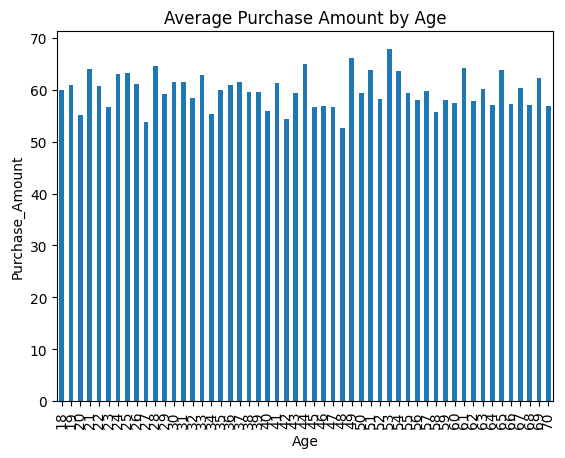

In [11]:
# Age vs Purchase
age_purchase = df.groupby('Age')['Purchase_Amount'].mean()
plt.figure()
age_purchase.plot(kind='bar')
plt.title('Average Purchase Amount by Age')
plt.xlabel('Age')
plt.ylabel('Purchase_Amount')
plt.show()

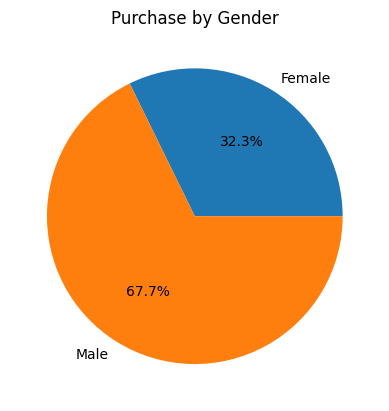

In [12]:
# Gender vs Purchase
gender_purchase = df.groupby('Gender')['Purchase_Amount'].sum()
plt.figure()
gender_purchase.plot(kind='pie', autopct='%1.1f%%')
plt.title('Purchase by Gender')
plt.ylabel('')
plt.show()

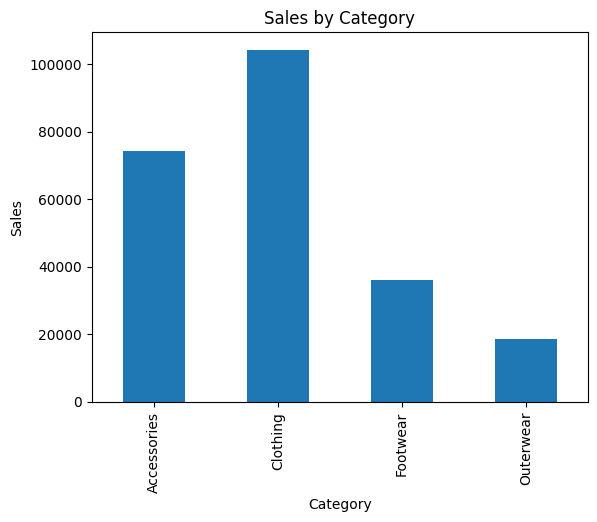

In [13]:
# Category analysis
category_sales = df.groupby('Category')['Purchase_Amount'].sum()
plt.figure()
category_sales.plot(kind='bar')
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

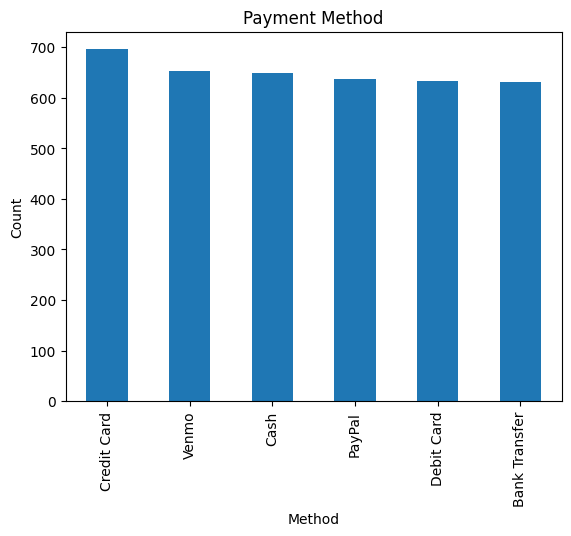

In [14]:
# Payment method
payment_method = df['Payment Method'].value_counts()
plt.figure()
payment_method.plot(kind='bar')
plt.title('Payment Method')
plt.xlabel('Method')
plt.ylabel('Count')
plt.show()


In [16]:
# Top customers
top_customers = df.groupby('Customer ID')['Purchase_Amount'].sum().sort_values(ascending=False).head(10)
print(top_customers)


Customer ID
1480    100
1457    100
1592    100
2072    100
1422    100
1413    100
1406    100
1848    100
770     100
2843    100
Name: Purchase_Amount, dtype: int64


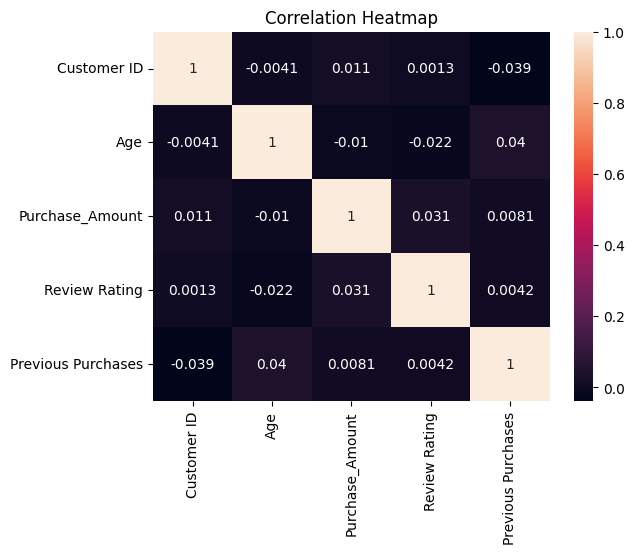

In [17]:
# Correlation
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title('Correlation Heatmap')
plt.show()